In [2]:
pip install pandas numpy matplotlib openpyxl

In [3]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print(df.head())

Saving sales_data_cleaning_project.csv to sales_data_cleaning_project.csv
   Order ID Customer Name       Product     Category  Quantity    Price  \
0      1001  Aarav Sharma        Laptop  Electronics       2.0  55000.0   
1      1002   Priya Reddy    Headphones  electronics       1.0   2500.0   
2      1003   Rohan Kumar  Office Chair    Furniture       1.0      NaN   
3      1004   Sneha Patel         Mouse  ELECTRONICS       3.0    800.0   
4      1005  Vikram Singh          Desk    Furniture       1.0  12000.0   

   Sales Date  
0  2025-01-05  
1  2025-01-12  
2  2025-02-03  
3  2025-02-10  
4  2025-03-01  


In [4]:
df.fillna({
    "Quantity": df["Quantity"].median(),
    "Price": df["Price"].mean()
}, inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df["Category"] = df["Category"].str.title()
df["Product"] = df["Product"].str.strip()

In [7]:
df["Sales Date"] = pd.to_datetime(df["Sales Date"])

In [8]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [9]:
total_sales = df["Revenue"].sum()
total_orders = len(df)
avg_order_value = df["Revenue"].mean()

print("Total Sales:", total_sales)
print("Total Orders:", total_orders)
print("Average Order Value:", avg_order_value)

Total Sales: 163557.0
Total Orders: 10
Average Order Value: 16355.7


In [10]:
category_report = df.groupby("Category")["Revenue"].sum()

print(category_report)

Category
Electronics    141300.0
Furniture       21807.0
Stationery        450.0
Name: Revenue, dtype: float64


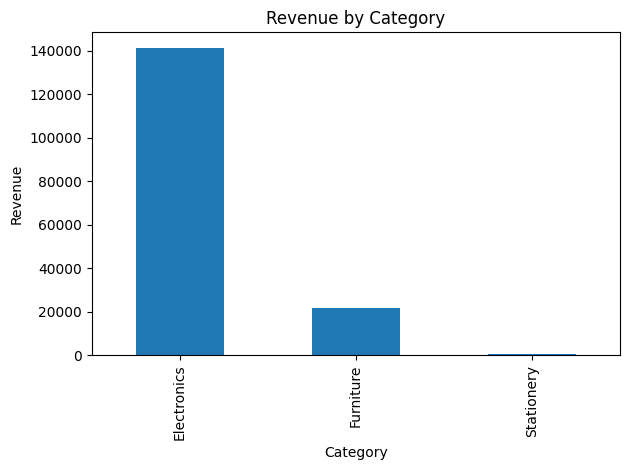

In [11]:
import matplotlib.pyplot as plt

category_report.plot(kind="bar")
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

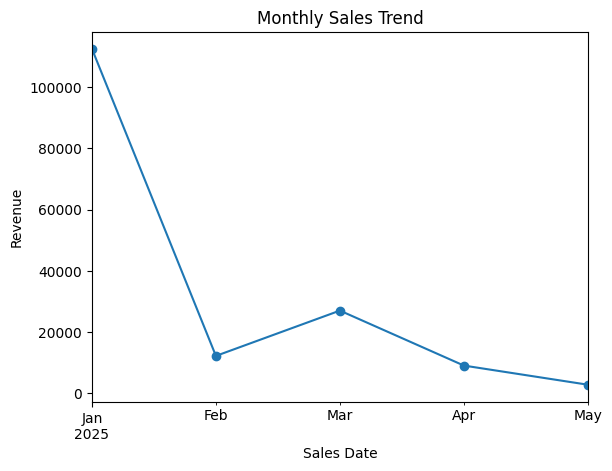

In [12]:
monthly_sales = df.groupby(
    df["Sales Date"].dt.to_period("M")
)["Revenue"].sum()

monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Revenue")
plt.show()

In [13]:
with pd.ExcelWriter("Automated_Report.xlsx") as writer:
    df.to_excel(writer, sheet_name="Cleaned Data", index=False)
    category_report.to_excel(writer, sheet_name="Category Report")

In [14]:
from google.colab import files


df.to_csv("cleaned_sales_data.csv", index=False)


files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
from google.colab import files
uploaded = files.upload()

Saving cleaned_sales_data.csv to cleaned_sales_data (1).csv


In [16]:
import pandas as pd

def automate_reporting(file_path):

    df = pd.read_csv(file_path)

    df.drop_duplicates(inplace=True)

    df.fillna(0, inplace=True)

    df["Category"] = df["Category"].str.title()

    df["Revenue"] = df["Quantity"] * df["Price"]

    report = df.groupby("Category")["Revenue"].sum()

    report.to_excel("Final_Report.xlsx")

    print("Report Generated Successfully!")

automate_reporting("cleaned_sales_data.csv")

Report Generated Successfully!
